In [1]:
import os
import glob
import sys
import ast

import anndata
import cassiopeia as cas
import matplotlib.pyplot as plt
import mplscience
import networkx as nx
import ngs_tools as ngs
import numpy as np
import pandas as pd
import pickle as pic
import scanpy as sc
import scipy
import seaborn as sns
import squidpy as sq
from tqdm.auto import tqdm

SPATIAL_PACKAGE="/path/to/spatial/analysis/package"
DATA_DIR="/path/to/kpspatial/dataset/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import target_site_utilities, spatial_utilities
from utilities.tree_utilities import get_leaf_coordinates

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/treedata/_core/read.py:19: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  ANDATA_VERSION = version.parse(ad.__version__)


## Plot simulations for resolving allele conflicts

In [29]:
triplet_rows = []
rf_rows = []
for pkl_path in tqdm(glob.glob(f'{DATA_DIR}/simulations/amibiguous_simulated_trees/40_2000_*/*/*/*/*_critique.pkl.gz')):
    split = pkl_path.split('/')[-7:]
    ground_truth_uuid = split[2]
    subsampled_uuid = split[-2]
    t = split[-1].split('_')[0]
    method = split[3]
    ratio = float(split[4])

    
    triplet_critique, rf_critique = ngs.utils.read_pickle(pkl_path)
    triplet_rows.extend([[
        ground_truth_uuid,
        subsampled_uuid,
        t,
        method,
        ratio,
        depth,
        triplet_critique[0][depth],
        triplet_critique[1][depth],
        triplet_critique[2][depth],
        triplet_critique[3][depth],
    ] for depth in triplet_critique[0].keys()])
    rf_rows.append([ground_truth_uuid, subsampled_uuid, t, method, ratio, rf_critique[0], rf_critique[1]])

df_triplets = pd.DataFrame(
    triplet_rows,
    columns=[
        'ground_truth_uuid',
        'subsampled_uuid',
        'type',
        'method',
        'ratio',
        'depth',
        'all_correct',
        'resolvable_correct',
        'unresolved_correct',
        'proportion_unresolvable'
    ]
)
df_triplets['type-method'] = df_triplets['type'] + '-' + df_triplets['method']

df_rf = pd.DataFrame(rf_rows, columns=['ground_truth_uuid', 'subsampled_uuid', 'type', 'method', 'ratio', 'distance', 'max_distance'])
df_rf['normalized_distance'] = df_rf['distance'] / df_rf['max_distance']
df_rf['type-method'] = df_rf['type'] + '-' + df_rf['method']

  0%|          | 0/1728 [00:00<?, ?it/s]

### Extended Data Figure 2a

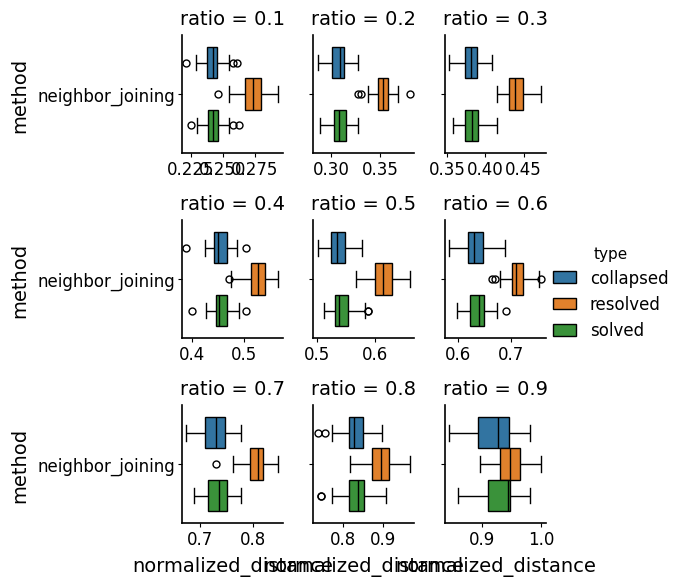

In [30]:
with mplscience.style_context():
    sns.catplot(
        data=df_rf[df_rf['method'] == 'neighbor_joining'].groupby(['ground_truth_uuid', 'subsampled_uuid', 'ratio', 'type', 'method']).agg({'normalized_distance': 'mean'}).reset_index(),
        x='normalized_distance',
        y='method',
        hue='type',
        kind='box',
        col='ratio',
        col_wrap=3,
        height=2,
        aspect=1,
        linewidth=1,
        linecolor='black',
        sharex=False
    )
    plt.show()

## Plot imputation simulations

In [33]:
def reconstruct_and_evaluate(full_tree, missing_tree, knn_tree, solver):
    
    reconstructed_missing_tree = cas.data.CassiopeiaTree(character_matrix = missing_tree.character_matrix.copy())
    solver.solve(reconstructed_missing_tree)
    reconstructed_missing_tree.collapse_mutationless_edges(infer_ancestral_characters=True)
    reconstructed_missing_tree.collapse_unifurcations()

    rf_missing, rf_max_missing = cas.critique.compare.robinson_foulds(reconstructed_missing_tree, full_tree)
    triplets_missing = cas.critique.compare.triplets_correct(full_tree, reconstructed_missing_tree, number_of_trials=500)

    imputed_knn_10_tree = cas.data.CassiopeiaTree(character_matrix = knn_tree.character_matrix.copy())
    solver.solve(imputed_knn_10_tree)
    imputed_knn_10_tree.collapse_mutationless_edges(infer_ancestral_characters=True)
    imputed_knn_10_tree.collapse_unifurcations()

    rf_imputed, rf_max_imputed = cas.critique.compare.robinson_foulds(imputed_knn_10_tree, full_tree)
    triplets_imputed = cas.critique.compare.triplets_correct(full_tree, imputed_knn_10_tree, number_of_trials=500)
    
    return (rf_missing/rf_max_missing, triplets_missing, rf_imputed/rf_max_imputed, triplets_imputed)

def assess_imputation_accuracy(full_tree, missing_tree, knn_tree):

    full_character_matrix = full_tree.character_matrix.copy()
    missing_character_matrix = missing_tree.character_matrix.copy()
    imputed_character_matrix = knn_tree.character_matrix.copy()

    missing_rate = (missing_character_matrix == -1).sum(axis=1).sum() / (missing_character_matrix.shape[0] * missing_character_matrix.shape[1])
    
    missing_inds = np.where(missing_character_matrix == -1)
    n_correct, n_imputed = 0, 0
    
    for (i, j) in zip(missing_inds[0], missing_inds[1]):
        
        imputed_state = imputed_character_matrix.iloc[i, j]
        ground_truth_state = full_character_matrix.iloc[i, j]
        
        if imputed_state != -1:
            
            n_correct += (imputed_state == ground_truth_state)
            n_imputed += 1

    return missing_rate, (n_correct/n_imputed)


def impute_missing(tree, spatial_coordinates, minimum_proportion=0.0, num_imputation_iterations=1, radius=30, k=None, min_votes=1):
    
    adata = anndata.AnnData(obs = pd.DataFrame(index = spatial_coordinates.index), obsm={'spatial': spatial_coordinates[['x', 'y']].values})
    character_matrix = tree.character_matrix.copy()
    
    # compute spatial neigbhorhoods
    if k:
        sq.gr.spatial_neighbors(
                adata, coord_type="generic", spatial_key="spatial", n_neighs=k
            )
    else:
        sq.gr.spatial_neighbors(
                adata, coord_type="generic", spatial_key="spatial", radius=radius
            )
    
    spatial_graph = nx.from_numpy_array(adata.obsp["spatial_connectivities"])
    node_map = dict(
        zip(
            range(adata.obsp["spatial_connectivities"].shape[0]),
            adata.obs_names,
        )
    )
    spatial_graph = nx.relabel_nodes(spatial_graph, node_map)

    prev_character_matrix_imputed = character_matrix.copy()
    missing_indices = np.where(character_matrix == -1)

    for _round in range(num_imputation_iterations):
        character_matrix_imputed = prev_character_matrix_imputed.copy()
        missing_indices = np.where(prev_character_matrix_imputed == -1)

        for i, j in tqdm(zip(missing_indices[0], missing_indices[1]), total=len(missing_indices[0])):


            (
                imputed_value,
                prop_votes,
                num_votes,
            ) = target_site_utilities.impute_single_state(
                prev_character_matrix_imputed.index.values[i],
                j,
                prev_character_matrix_imputed,
                neighborhood_graph=spatial_graph,
                number_of_hops=1,
            )
            if (
                prop_votes > minimum_proportion
                and num_votes > min_votes
                and imputed_value != -1
            ):
                character_matrix_imputed.iloc[i, j] = imputed_value

        prev_character_matrix_imputed = character_matrix_imputed.copy()

    tree.character_matrix = character_matrix_imputed
    tree.set_character_states_at_leaves()
    

In [35]:
simulation_directory = f'{DATA_DIR}/simulations/imputation_simulations_mutation_rate_0.7/'

nj_solver = cas.solver.NeighborJoiningSolver(add_root=True, fast=False)
greedy_solver = cas.solver.VanillaGreedySolver()
hybrid_solver = cas.solver.HybridSolver(top_solver=greedy_solver, bottom_solver=nj_solver, cell_cutoff=800, threads=8)

performance_summary = pd.DataFrame(columns=['Dropout', 'Replicate', 'Algorithm', 'Imputation', 'RF', 'Triplets', 'MissingRate', 'ImputationAccuracy'])
for dropout in tqdm(os.listdir(simulation_directory)):
        
    if not os.path.isdir(f"{simulation_directory}/{dropout}"):
        continue
        
    for iteration in tqdm(range(5)):
        print(dropout, iteration)
        
        full_tree = pic.load(open(f"{simulation_directory}/{dropout}/simulated_tree_{iteration}.pkl", 'rb'))
        full_tree.collapse_unifurcations()
        missing_tree = pic.load(open(f"{simulation_directory}/{dropout}/simulated_tree_{iteration}.missing.pkl", 'rb'))
        
        knn_tree = missing_tree.copy() 
        impute_missing(knn_tree, get_leaf_coordinates(knn_tree), minimum_proportion=0.8, num_imputation_iterations=3, k=10, min_votes=5)
        # knn_impute_missing(knn_tree, k = 10, minimum_proportion=0.8)

        missing_rate, imputation_accuracy = assess_imputation_accuracy(full_tree, missing_tree, knn_tree)
        
        rf_missing, triplets_missing, rf_imputed, triplets_imputed = reconstruct_and_evaluate(full_tree, missing_tree, knn_tree, nj_solver)
        new_row_missing_nj = pd.DataFrame([[dropout, iteration, 'NeighborJoining', 'None', rf_missing, np.mean(list(triplets_missing[0].values())), missing_rate, imputation_accuracy]], columns=performance_summary.columns)
        new_row_imputed_nj = pd.DataFrame([[dropout, iteration, 'NeighborJoining', 'KNN-10', rf_imputed, np.mean(list(triplets_imputed[0].values())), missing_rate, imputation_accuracy]], columns=performance_summary.columns)

        finished=False
        while not finished:
            try:
                rf_missing, triplets_missing, rf_imputed, triplets_imputed = reconstruct_and_evaluate(full_tree, missing_tree, knn_tree, hybrid_solver)
                finished=True
            except:
                finished=False
        new_row_missing_hybrid = pd.DataFrame([[dropout, iteration, 'Greedy+NJ', 'None', rf_missing, np.mean(list(triplets_missing[0].values())), missing_rate, imputation_accuracy]], columns=performance_summary.columns)
        new_row_imputed_hybrid = pd.DataFrame([[dropout, iteration, 'Greedy+NJ', 'KNN-10', rf_imputed, np.mean(list(triplets_imputed[0].values())), missing_rate, imputation_accuracy]], columns=performance_summary.columns)
        
        performance_summary = pd.concat([performance_summary, new_row_missing_nj, new_row_imputed_nj,
                                        new_row_missing_hybrid, new_row_imputed_hybrid])

In [11]:
performance_summary['Dropout'] = performance_summary.apply(lambda x: float(x.Dropout.split("_")[1]), axis=1)
performance_summary.head(5)

,Dropout,Replicate,Algorithm,Imputation,RF,Triplets,MissingRate,ImputationAccuracy
0,0.5,0,NeighborJoining,None,0.969138,0.2132,0.499346,0.954491
0,0.5,0,NeighborJoining,KNN-10,0.962069,0.3418,0.499346,0.954491
0,0.5,0,Greedy+NJ,None,0.972973,0.3229,0.499346,0.954491
0,0.5,0,Greedy+NJ,KNN-10,0.958850,0.3562,0.499346,0.954491
0,0.5,1,NeighborJoining,None,0.957889,0.2820,0.503769,0.877263


### Extended Data Figure 2e 

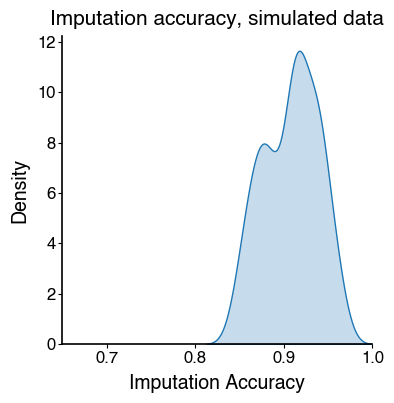

In [12]:
with mplscience.style_context():
    sns.kdeplot(performance_summary, x = 'ImputationAccuracy', fill=True)
    plt.xlim(0.65, 1.0)
    plt.xlabel("Imputation Accuracy")
    plt.title("Imputation accuracy, simulated data")
    plt.show()

### Extended Data Figure 2f-g

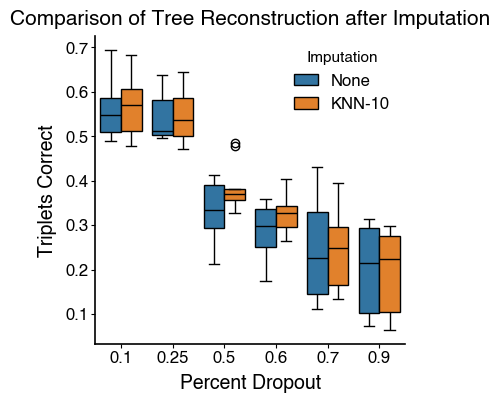

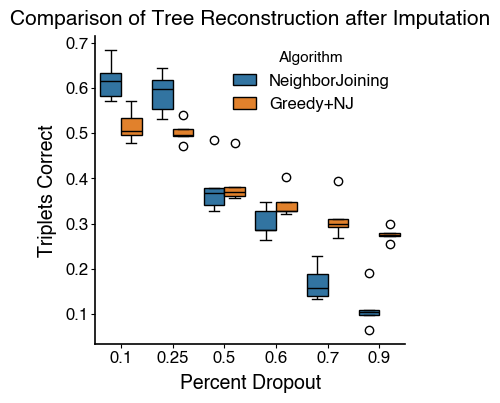

In [15]:
with mplscience.style_context():
    sns.boxplot(data=performance_summary, x='Dropout', y='Triplets', hue='Imputation', linecolor='black')
    plt.ylabel("Triplets Correct")
    plt.xlabel("Percent Dropout")
    plt.title("Comparison of Tree Reconstruction after Imputation")
    # plt.savefig("figures/triplets_correct_k10_imputation.pdf", bbox_inches='tight')
    plt.show()

with mplscience.style_context():
    sns.boxplot(data=performance_summary[performance_summary['Imputation'] == 'KNN-10'], x='Dropout', y='Triplets', hue='Algorithm', linecolor='black')
    plt.ylabel("Triplets Correct")
    plt.xlabel("Percent Dropout")
    plt.title("Comparison of Tree Reconstruction after Imputation")
    # plt.savefig("figures/triplets_correct_k10_imputation_algorithm.pdf", bbox_inches='tight')
    plt.show()

## Semi-synthetic experiments (i.e., held-out real data)

In [36]:
ts_meta = pd.read_csv("./data/sample_target_site_meta.tsv", sep='\t', index_col = 0)
ts_meta = ts_meta.set_index('sample_name')
ts_meta.head(5)

,index,percent_unique,percent_missing,median_umi
sample_name,,,,
B94_04,0,0.446997,0.629659,UMI 4.0\ndtype: float64
B94_20,0,0.960645,0.712516,UMI 3.0\ndtype: float64
B94_23,0,0.942466,0.775342,UMI 3.0\ndtype: float64
B95_24,0,0.987395,0.697059,UMI 3.0\ndtype: float64
B99_22,0,0.852861,0.766175,UMI 3.0\ndtype: float64


### Figure 1D

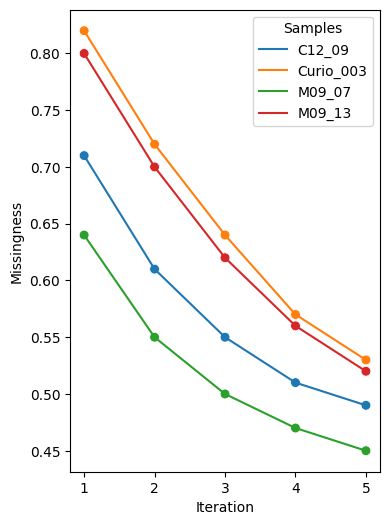

In [37]:
# derived from standard output from imputation script

missingness = pd.DataFrame.from_dict({
      'Samples': ['C12_09']*5 + ['Curio_003']*5 + ['M09_07']*5 + ['M09_13']*5,
      'Iteration': [1,2,3,4,5]*4,
      'Missingness': [0.71, 0.61, 0.55, 0.51, 0.49] + [0.82, 0.72, 0.64, 0.57, 0.53] + [0.64, 0.55, 0.50, 0.47, 0.45] + [0.8, 0.7, 0.62, 0.56, 0.52]
},
orient='columns')

h = plt.figure(figsize=(4, 6))
sns.lineplot(data=missingness, x='Iteration', y='Missingness', hue='Samples')
sns.scatterplot(data=missingness, x='Iteration', y='Missingness', hue='Samples', legend=False, s=50)
plt.xticks([1, 2, 3, 4, 5], [1,2,3,4,5])
plt.show()

### Extended Data Figure 2h-j

0.8947368421052632
0.6966991341991342
35.72787528387517


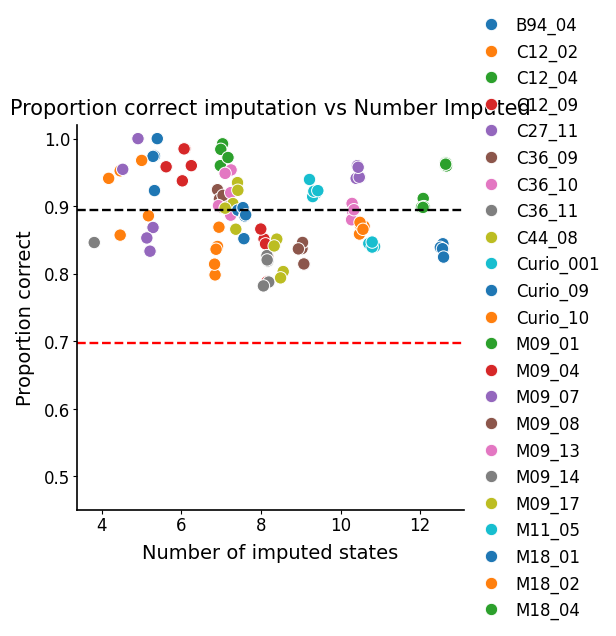

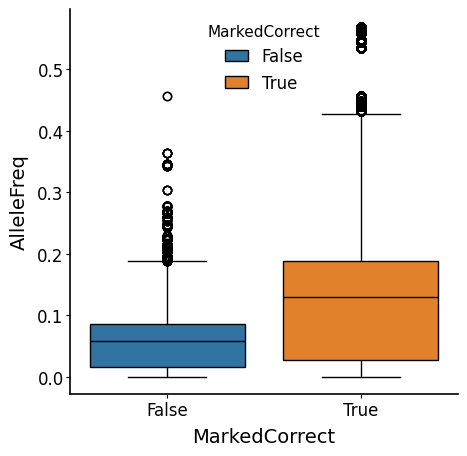

In [38]:
imputation_log = pd.read_csv("./data/semisynthetic_imputation_results.tsv", sep='\t', index_col = 0)
random_imputation_log = pd.read_csv("./data/semisynthetic_imputation_results.random.tsv", sep='\t', index_col = 0)

prop_correct = lambda x: len(x[x == True]) / len(x)

accuracies = imputation_log.groupby(['SampleName', 'NumIterations', 'Replicate']).agg({'MarkedCorrect': prop_correct, 'ImputedState': len}).reset_index()
random_accuracies = random_imputation_log.groupby(['SampleName', 'NumIterations', 'Replicate']).agg({'MarkedCorrect': prop_correct, 'ImputedState': len}).reset_index()
# accuracies = accuracies.groupby(['SampleName', 'NumIterations']).agg({'MarkedCorrect': 'median', 'ImputedState': 'median'})

accuracies = accuracies[accuracies['ImputedState'] > 10]
accuracies['ImputedState'] = np.log2(1 + accuracies['ImputedState'])

random_accuracies = random_accuracies[random_accuracies['ImputedState'] > 10]
random_accuracies['ImputedState'] = np.log2(1 + random_accuracies['ImputedState'])

accuracies['percent_missing'] = accuracies.apply(lambda x: ts_meta.loc[x.SampleName, 'percent_missing'], axis=1)
accuracies['percent_unique'] = accuracies.apply(lambda x: ts_meta.loc[x.SampleName, 'percent_unique'], axis=1)

accuracies = accuracies[accuracies['NumIterations'] == 5]
print(accuracies['MarkedCorrect'].median())
print(random_accuracies['MarkedCorrect'].median())

print((random_accuracies['ImputedState'].median() / accuracies['ImputedState'].median() * accuracies['ImputedState'].median())**2)

with mplscience.style_context():
    h = plt.figure(figsize=(5,5))
    ax = plt.gca()
    sns.scatterplot(data=accuracies, x='ImputedState', y='MarkedCorrect', hue='SampleName', palette='tab10', s=80)
    plt.axhline(y=accuracies['MarkedCorrect'].median(), color='black', linestyle='dashed')

    plt.axhline(y=random_accuracies['MarkedCorrect'].median(), color='red', linestyle='dashed')
    plt.ylim(0.45, 1.02)
    plt.xlabel("Number of imputed states")
    plt.ylabel("Proportion correct")
    plt.title("Proportion correct imputation vs Number Imputed")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

with mplscience.style_context():
    h = plt.figure(figsize=(5,5))
    sns.boxplot(imputation_log, x='MarkedCorrect', y='AlleleFreq', hue='MarkedCorrect', linecolor='black')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

0.021890088585757236


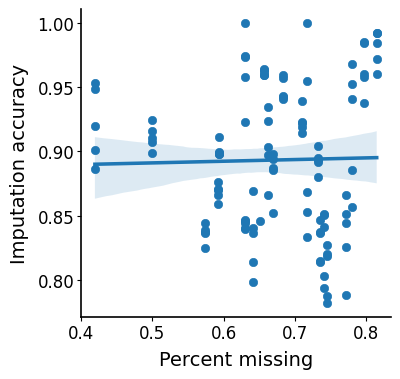

In [15]:
with mplscience.style_context():

    print(scipy.stats.pearsonr(accuracies.loc[accuracies['NumIterations'] == 5, 'percent_missing'], accuracies.loc[accuracies['NumIterations'] == 5, 'MarkedCorrect'])[0])
    
    sns.scatterplot(data=accuracies[accuracies['NumIterations'] == 5], x='percent_missing', y='MarkedCorrect', edgecolor=None)
    sns.regplot(data=accuracies[accuracies['NumIterations'] == 5], x='percent_missing', y='MarkedCorrect', scatter=False)
    plt.xlabel("Percent missing")
    plt.ylabel("Imputation accuracy")
    plt.show()

### Extended Data Figure 2k

In [40]:
SAMPLES=["B94_04", "B94_20", "B95_24", "B99_22",
        "C12_01", "C12_02", "C12_04", "C12_03", "C12_05",
        "C12_09", "C12_10", "C12_12",
        "C27_11", "M09_01",
        "M09_04", "M09_07", "M09_08",
        "C36_09", "C36_10", "C36_11", "Curio_09",
        "Curio_10", "M09_11", "M09_13", "M09_14",
        "M09_17", "M09_18", "M11_05", "M18_01",
        "M18_02", "M18_04", "C44_06", "C44_08",
        "Curio_001", "M11_06", "M18_06",
        "M11_08", "M18_17", "M11_14",
        "M18_13", "Curio_002", "Curio_003", "Curio_004"
         ]

missing_to_merge = []
for sample_name in tqdm(SAMPLES):
    
    character_matrix_imputed = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{sample_name}_character_matrix.tsv', sep='\t', index_col = 0)
    for col in character_matrix_imputed:
        character_matrix_imputed[col] = character_matrix_imputed[col].apply(
            lambda x: ast.literal_eval(str(x))
        )
    
    missing_rate = ts_meta.loc[sample_name, 'percent_missing']
    missing_rate_imputed = (character_matrix_imputed == -1).sum(axis=1).sum() / (character_matrix_imputed.shape[0] * character_matrix_imputed.shape[1])

    new_df = pd.DataFrame([[sample_name, missing_rate, missing_rate_imputed]], columns=['sample_name', 'missing_rate', 'imputed_missing_rate'])
    missing_to_merge.append(new_df)

missing_summary = pd.concat(missing_to_merge)
missing_summary.head(5)


  0%|          | 0/43 [00:00<?, ?it/s]

/tmp/ipykernel_1257143/1125645499.py:18: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  character_matrix_imputed = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{sample_name}_character_matrix.tsv', sep='\t', index_col = 0)
/tmp/ipykernel_1257143/1125645499.py:18: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  character_matrix_imputed = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{sample_name}_character_matrix.tsv', sep='\t', index_col = 0)
/tmp/ipykernel_1257143/1125645499.py:18: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  character_matrix_imputed = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{sample_n

,sample_name,missing_rate,imputed_missing_rate
0,B94_04,0.629659,0.278120
0,B94_20,0.712516,0.595772
0,B95_24,0.697059,0.670077
0,B99_22,0.766175,0.698747
0,C12_01,0.801435,0.755614


/tmp/ipykernel_1257143/3270836196.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


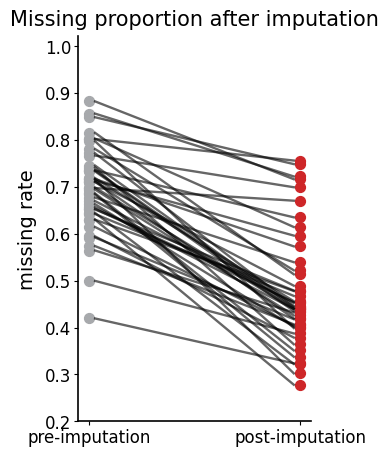

In [41]:
missing_summary['recovery'] = missing_summary.apply(lambda x: 1.0 - x.imputed_missing_rate / x.missing_rate, axis=1)

with mplscience.style_context():
    h = plt.figure(figsize=(3,5))
    ax = plt.gca()
    for _, entry in missing_summary.iterrows():
        plt.plot([0.03, 0.97], [entry.missing_rate, entry.imputed_missing_rate], color='black', alpha=0.6)
    for _, entry in missing_summary.iterrows():
        plt.scatter([0], [entry.missing_rate], color='#A7A9AC', s=50)
        plt.scatter([1], [entry.imputed_missing_rate], color='#CE2628', s=50)
        
    plt.ylim(0.2, 1.02)
    plt.xticks([0, 1], ['pre-imputation', 'post-imputation'])
    plt.ylabel("missing rate")
    plt.title("Missing proportion after imputation")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()